# Path analysis from experimental videos (Silla SAMU)

## Introduction

This program allows obtaining the trajectory parameters from images captured during experiments in SAMU. It receives the folder where the sequence of photos are stored, and generates a set of parameters associated to it in csv format with the same name as the folder containing the photos. Read the following section for a description of these parameters. 

## Parameters description

+ The normalized effective distance (NED), which relates the optimal path (mp) to the real trajectory (rt), as shown in equation below (the NED is a good indicator for comparing the motions performed by the user to the optimal route);

$NED = \frac{rt}{mp}$

+ Movement variability (MV)  represents the extent to which the sample points lie in a straight line along an axis parallel to the optimal path (Equation belows shows the expression, assuming that the optimal route is y = 0 and n is the number of samples in the real trajectory); 

$MV = \sqrt{ \frac{\sum(y_i - \overline{y})^2}{n-1}}$

+ Movement error (ME) is the average deviation of the sample points from the optimum path, regardless of whether the points are above or below (assuming y = 0 as an optimal path); 

$ME = \frac{\sum|{y_i}|}{n}$


+ Movement offset (MO)is the mean deviation of sample points from the optimum path (Equation (13), assuming y = 0 as the optimal path), which indicates the tendency of the pointer to move “left” or “right” from the optimal path;

$MO = \frac{\sum{y_i}}{n}$






Reference: I. S. MacKenzie, T. Kauppinen, and M. Silfverberg. Accuracy measures for evaluating computer
pointing devices. In Proceedings of the SIGCHI Conference on Human Factors in Computing
Systems, pages 9–16.



## Procedure


For NED we will follow a different approach consisting in measuring the length of the trajectory using the Hall sensors to compare with the optimal path. For the remainder parameters we will apply the following steps:


1) Open an image using OpenCV

2) Segmentate the image by color. 

3) Find the point of the line that is nearest to the center of the image, which is considered the current position of the wheelchair.

4) The application must take into account that the line can be out of the camera. 


For each image, an output is generated containing the image identifier, the position of point that belongS to the line that minimizes the distance to the center of the image. The center of image is considered the current position of the wheelchair, while that the coordinates given are assumed to be the position of the optimal or ideal path. 

If there is a problem in processing the image, the output identifies the cause by an error code associated to it, which can be one of the following: 1) Segmentation by color was not possible 2)  No line was detected 2) Other  

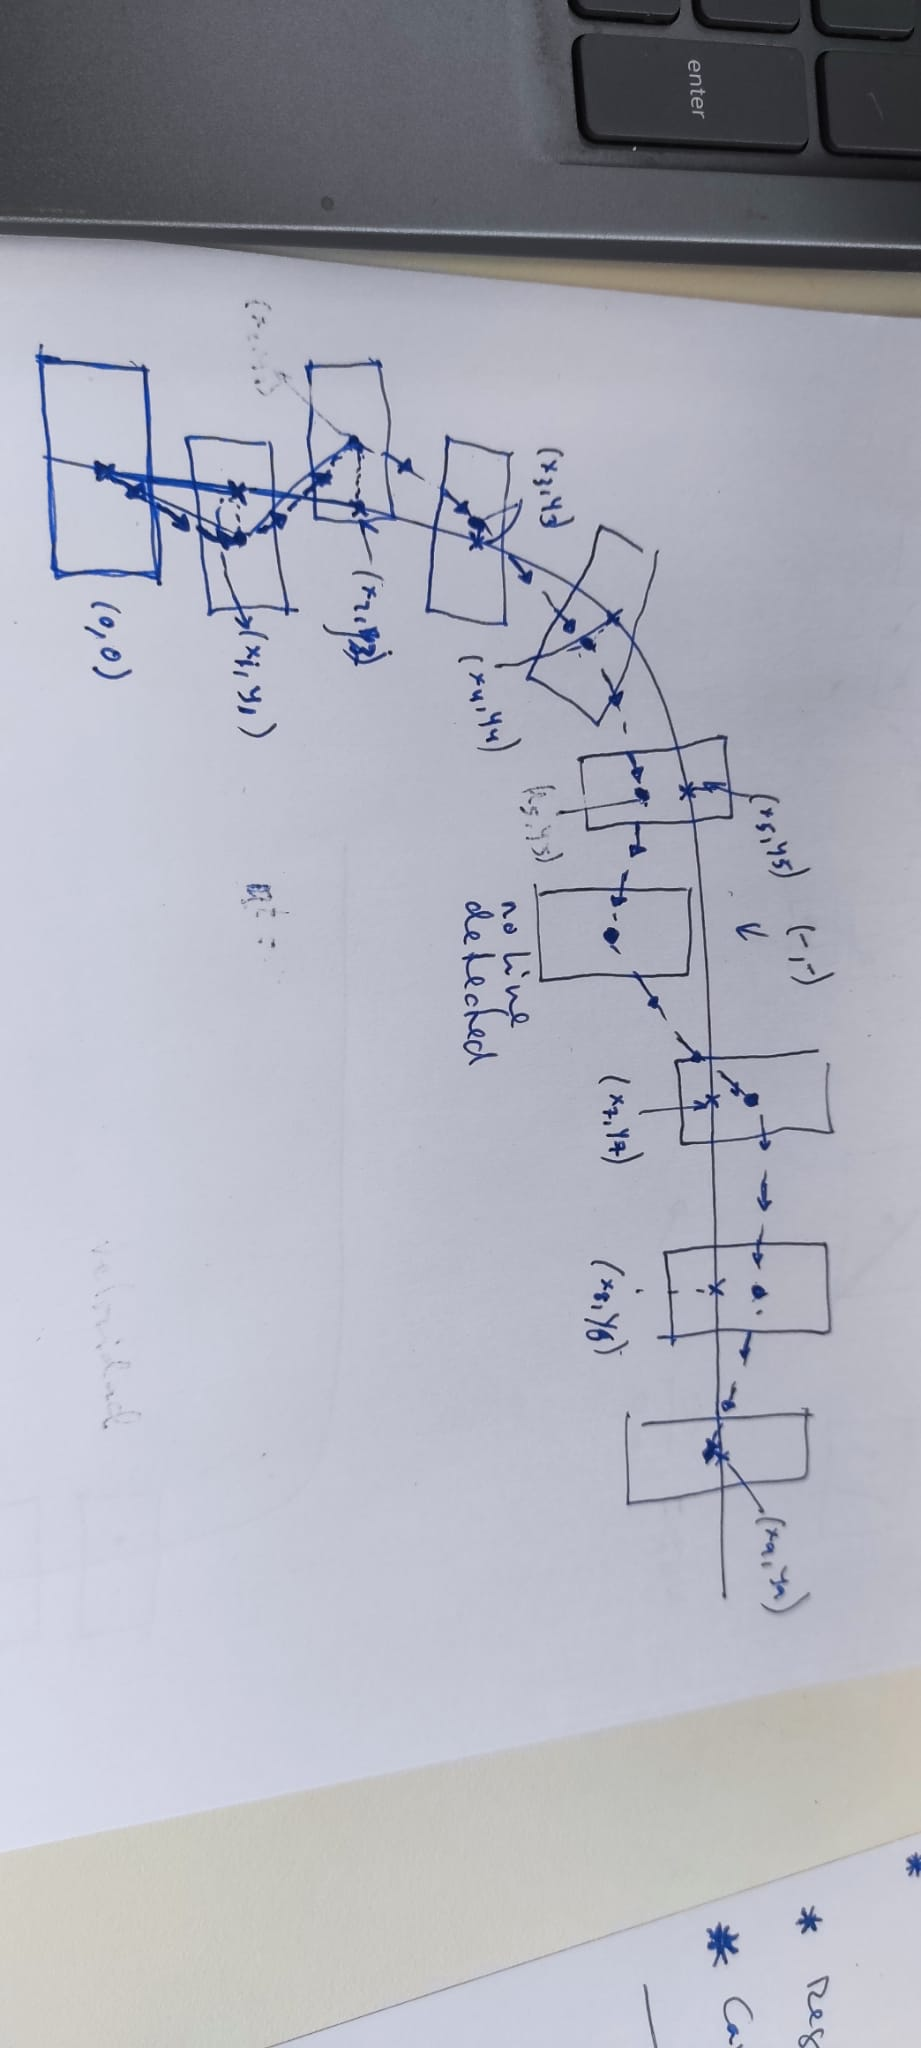


It is important to take into consideration the conversion rate to transform all metrics into cm. 

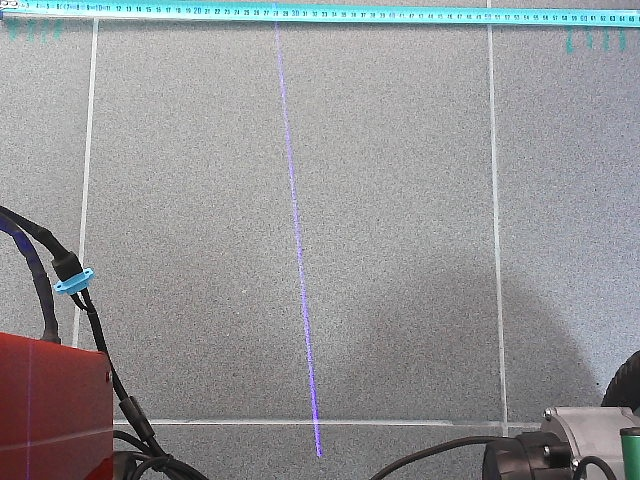

The webcam model is w4ds that, according to the datasheet, has an FOV of 78º. As the height of the webcam is  69cm over the floor and focused towards it, the image width would be of 111.75cm. However, the measured image width is of 66cm as can be seen on the figure above. Given a image resolution of 480x640, it turns out that the ratio is of 66cm/640px = 0.103 cm/px. 

Regarding the metrics, the orthogonal distance between the the trajectory line path and the center of the image is obtained. To do that, we estimate the equation of the line that fits the line path given a point $(x_0,y_0)$ and its direction $\alpha4.

$A x + By + C=0$ 

where $m = -\tan (\alpha)$, $A = -m$, $ = -1$, and $C= m x_0 - y_0$.

The line equation above is considered the reference for metrics, the distance of the center of the image to the line the value $y_i$ used to get those metrics. So, the distance of a point to a line is 

$y_i = \frac{\|{A x_c + B y_c + C}\|}{\sqrt{A^2 + B^2}}$


We applied the following approach:

Let d be $d = A x_c + By_c + C$, and  let s be $s= sign(d) sign(m)$. S gives the sign of $y_i$ considering that it is possitive when the wheelchair deviates from the central line towards the right, and negative to the left. Therefore

$y_i = \frac{{A x_c + B y_c + C}}{\sqrt{A^2 + B^2}} \times sign( m)$


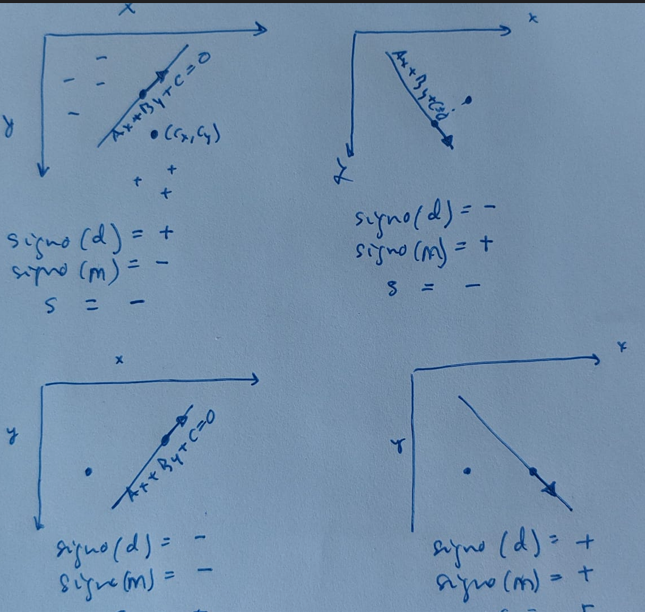

In [1]:

import numpy as np
import os
import cv2
import math

ratio = 0.103   #conversion ratio in cm/px

def trajectory_parameters(ent, val):
    pos = np.where(val==1)
    mv = np.sqrt(np.var(ent[pos],ddof=1))
    me = np.sum(np.abs(ent[pos]))/len(ent[pos])
    mo = np.sum(ent[pos])/len(ent[pos])
    
    return mv,me,mo



def cargar_imagenes_de_directorio(ruta_directorio):
    """
    Carga todas las imágenes (archivos .jpg, .png, etc.) de un directorio dado.

    Args:
        ruta_directorio (str): La ruta completa del directorio donde están las imágenes.

    Returns:
        list: Una lista de tuplas, donde cada tupla contiene (nombre_archivo, imagen_cargada).
              Retorna una lista vacía si el directorio no existe o no contiene imágenes.
    """
    imagenes = []
    if not os.path.isdir(ruta_directorio):
        print(f"Error: El directorio '{ruta_directorio}' no existe.")
        return imagenes

    print(f"Buscando imágenes en: {ruta_directorio}")
    for nombre_archivo in os.listdir(ruta_directorio):
        # Construye la ruta completa al archivo
        ruta_completa_archivo = os.path.join(ruta_directorio, nombre_archivo)

        # Verifica si es un archivo (no un subdirectorio)
        if os.path.isfile(ruta_completa_archivo):
            # Intenta leer la imagen. cv2.imread retorna None si no es una imagen válida.
            imagen = cv2.imread(ruta_completa_archivo)
            #imagen = cv2.cvtColor(imgagen, cv2.COLOR_BGR2RGB)
            if imagen is not None:
                imagenes.append((nombre_archivo, imagen))
                print(f"Cargada: {nombre_archivo}")
            else:
                print(f"Saltando archivo (no es una imagen o está corrupto): {nombre_archivo}")
    
    if not imagenes:
        print("No se encontraron imágenes en el directorio.")
    
    return imagenes


#def segmentar_curva_por_color(imagen, lower_hsv_bound=(40/2,0,0), upper_hsv_bound=(70/2,255,255)):
def segmentar_curva_por_color(imagen, lower_hsv_bound=(85, 100, 100), 
    upper_hsv_bound=(105, 255, 255)):
    """
    Segmenta una imagen por un rango de color HSV específico para encontrar la curva.

    Args:
        imagen (np.array): La imagen de entrada (en formato BGR de OpenCV).
        lower_hsv_bound (tuple): Tupla (H, S, V) que define el límite inferior del color.
        upper_hsv_bound (tuple): Tupla (H, S, V) que define el límite superior del color.

    Returns:
        np.array: Una imagen binaria (máscara) donde los píxeles de la curva son blancos (255)
                  y el resto son negros (0).
                  
    """
  
    """
    Segmenta una imagen por un rango de color HSV específico para encontrar la curva.

    Args:
        imagen (np.array): La imagen de entrada (en formato BGR de OpenCV).
        lower_hsv_bound (tuple): Tupla (H, S, V) que define el límite inferior del color.
        upper_hsv_bound (tuple): Tupla (H, S, V) que define el límite superior del color.

    Returns:
        np.array: Una imagen binaria (máscara) donde los píxeles de la curva son blancos (255)
                  y el resto son negros (0).
                  
    """
    
    
    # 1. Convertir la imagen de BGR a HSV
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

    # 2. Crear la máscara usando el rango de color HSV
    # Los píxeles dentro del rango serán blancos (255), el resto negros (0)
    mascara = cv2.inRange(hsv, lower_hsv_bound, upper_hsv_bound)

    return mascara


def esqueletizar_imagen(imagen_binaria):
    """
    Realiza la esqueletización de una imagen binaria (Zhang-Suen o similar).
    La imagen de entrada debe ser binaria (0 o 255).

    Args:
        imagen_binaria (np.array): La imagen binaria de entrada (máscara).

    Returns:
        np.array: La imagen esqueletizada (línea central del objeto).
    """
    # Asegurarse de que la imagen sea binaria (0 o 255) y de tipo CV_8UC1
    # Y que los objetos sean blancos (255) sobre fondo negro (0)
    imagen_binaria = imagen_binaria.copy() # Trabajar con una copia para no modificar la original
    if imagen_binaria.max() == 0: # Si la imagen está toda a cero (no hay objeto), retornar tal cual
        return imagen_binaria
    
    imagen_binaria[imagen_binaria == 255] = 1 # Convertir 255 a 1 para el algoritmo

    skeleton = np.zeros(imagen_binaria.shape, dtype=np.uint8)
    
    # Elemento estructurante para las operaciones de erosión y dilatación
    kernel = np.ones((3,3), np.uint8)

    while True:
        eroded = cv2.erode(imagen_binaria, kernel)
        dilated = cv2.dilate(eroded, kernel)
        
        # Diferencia entre la imagen erosionada y dilatada para obtener los "puntos límite"
        temp = cv2.subtract(imagen_binaria, dilated)
        
        # Intersección entre la imagen y los puntos límite para obtener los píxeles a eliminar
        # Esto es un paso crucial del algoritmo de esqueletización (Zhang-Suen)
        # Aquí simplificado, pero la idea es ir eliminando píxeles del borde
        # sin desconectar el esqueleto.
        
        # Para esqueletización más robusta, a veces se usa una secuencia de pasos más complejos.
        # Aquí estamos usando una aproximación más sencilla que es útil.
        # Una implementación común de Zhang-Suen:
        # P = np.zeros_like(eroded)
        # ... (lógica del algoritmo de Zhang-Suen, que es un poco larga) ...
        # If this is too complex, we can use a simpler approach for straight lines/simple curves
        
        # Para propósitos prácticos de extracción de línea central de una curva:
        # El algoritmo de Zhang-Suen es complejo para implementar "al vuelo" si no lo tienes.
        # Una alternativa más simple para líneas y curvas gruesas es el "thinning" o adelgazamiento.
        # Pero cv2.ximgproc.thinning() está en un módulo "contrib" y es más avanzado.
        
        # Vamos a usar una aproximación común para esqueletización que se ve en ejemplos de OpenCV
        # Usando cv2.erode y cv2.dilate de forma iterativa
        
        # Esta es una aproximación al algoritmo de Zhang-Suen
        # La idea es mantener el esqueleto y eliminar el resto
        
        # Si la imagen no tiene más píxeles que eliminar, el proceso se detiene.
        # Esto es una simplificación de un algoritmo de esqueletización.
        # Para una esqueletización robusta, especialmente en formas complejas,
        # cv2.ximgproc.thinning(src, thinningType) del módulo contrib de OpenCV sería ideal
        # pero requiere una instalación específica de opencv-contrib-python.

        # Dada la complejidad de Zhang-Suen manual, y que el usuario busca coordenadas de una curva,
        # voy a ofrecer una alternativa que se usa a veces o simplificar la lógica.

        # Mejor, vamos a usar una implementación de Zhang-Suen directamente, que es la más común:
        # Asegurarse que la imagen sea de tipo CV_8UC1 y que los valores sean 0 y 255
        
        # Convertir a 0 y 1 para el algoritmo, y de vuelta a 0 y 255 al final
        # La esqueletización iterativa que busca el esqueleto central.
        
        # Para el algoritmo de esqueletización, la imagen debe ser binaria con 0s y 1s.
        img_copy = imagen_binaria.copy()
        img_copy[img_copy == 255] = 1 # El algoritmo espera 0s y 1s

        skeleton = np.zeros(img_copy.shape, dtype=np.uint8)
        
        done = False
        while not done:
            eroded = cv2.erode(img_copy, kernel)
            temp = cv2.dilate(eroded, kernel)
            temp = cv2.subtract(img_copy, temp)
            
            # Condición de parada: Si no se eliminó ningún píxel en esta iteración
            done = np.sum(temp) == 0

            skeleton = cv2.bitwise_or(skeleton, temp) # Acumular los píxeles eliminados
            img_copy = eroded.copy() # Actualizar la imagen para la siguiente iteración

        return skeleton * 255 # Convertir de nuevo a 0 y 255

def contiene_linea(image,umbral=9):
    #This function tries to discern if the image contains a line or not
    #To accomplish this goal, the algorithm counts for white pixels in the image. If the
    #percentage is greater than a  given threshold, the image is considered to be valid.
    
    res = True
    if len(image.shape) > 2:
        print("Advertencia: La imagen no parece estar en escala de grises (tiene más de 2 dimensiones).")
        print("Se intentará convertir a escala de grises si es BGR o RGB.")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
    # Obtener el total de píxeles en la imagen
    total_pixels = image.shape[0] * image.shape[1]

    if total_pixels == 0:
        return 0.0 # Evitar división por cero

    # Contar los píxeles blancos (valor 255)
    # np.sum(imagen_grayscale == 255) cuenta cuántos elementos son True en la condición
    num_pixels_blancos = np.sum(image == 255)

    # Calcular el porcentaje
    porcentaje_blancos = (num_pixels_blancos / total_pixels) * 100
    if porcentaje_blancos > umbral or porcentaje_blancos<1:
        res=False

    return res, porcentaje_blancos


    

def encontrar_pixel_mas_cercano_al_centro(mascara_binaria):
    """
    Encuentra las coordenadas del píxel blanco de una máscara binaria
    que está más cerca del centro de la imagen.

    Args:
        mascara_binaria (np.array): La máscara binaria (blanco=255, negro=0).

    Returns:
        tuple or None: Las coordenadas (x, y) del píxel más cercano, o None si no hay píxeles blancos.
    """
    alto, ancho = mascara_binaria.shape
    centro_x, centro_y = ancho // 2, alto // 2

    # Obtener las coordenadas (filas, columnas) de todos los píxeles blancos
    # np.where devuelve dos arrays: uno para las filas y otro para las columnas
    filas_blancas, cols_blancas = np.where(mascara_binaria == 255)

    if len(filas_blancas) == 0:
        return None # No hay píxeles blancos en la máscara

    # Crear un array de puntos (x, y) para facilitar los cálculos
    puntos_blancos = np.column_stack((cols_blancas, filas_blancas)) # (x, y)

    # Calcular las distancias de todos los puntos al centro
    # Usamos np.linalg.norm para calcular la distancia euclidiana de forma eficiente
    distancias = np.linalg.norm(puntos_blancos - np.array([centro_x, centro_y]), axis=1)

    # Encontrar el índice del punto con la distancia mínima
    indice_mas_cercano = np.argmin(distancias)

    # Obtener las coordenadas del píxel más cercano
    pixel_mas_cercano_x, pixel_mas_cercano_y = puntos_blancos[indice_mas_cercano]

    return (pixel_mas_cercano_x, pixel_mas_cercano_y)
    

# --- EJEMPLO DE USO ---
if __name__ == "__main__":
    # ¡IMPORTANTE!: Reemplaza esta ruta con la ruta real de tu directorio de imágenes
    directorio_de_mis_imagenes = '.\\tests' # Ejemplo en Linux/macOS
    # directorio_de_mis_imagenes = 'C:\\Users\\TuUsuario\\MisImagenes' # Ejemplo en Windows

    lista_de_imagenes_cargadas = cargar_imagenes_de_directorio(directorio_de_mis_imagenes)
    
    y_i = np.zeros(len(lista_de_imagenes_cargadas))   #Distance to the center of the image
    v_i = np.zeros(len(lista_de_imagenes_cargadas))   #This matrix contains if the element y_i is correct or not
    angulo_i = np.zeros(len(lista_de_imagenes_cargadas))
    
    print(f"Resolución de las imágenes {lista_de_imagenes_cargadas[0][1].shape}")
    for n in range(len(lista_de_imagenes_cargadas)):
        amostrar=n
        print(f"\nSe han cargado {len(lista_de_imagenes_cargadas)} imágenes.")
        # Opcional: Mostrar la primera imagen para verificar
        print(f"Mostrando la primera imagen: {lista_de_imagenes_cargadas[amostrar][0]}")
        #cv2.imshow('imagen',cv2.resize(lista_de_imagenes_cargadas[amostrar][1],(500,500)))
        cv2.imshow(lista_de_imagenes_cargadas[amostrar][0],lista_de_imagenes_cargadas[amostrar][1])
        imagen_converted = segmentar_curva_por_color(lista_de_imagenes_cargadas[amostrar][1])
        #cv2.imshow('imagen2',cv2.resize(imagen_converted,(500,500)))
        cv2.imshow('imagen2',imagen_converted)
                   
        #imagen_converted = cv2.dilate(imagen_converted, np.ones((10,10),np.uint8), iterations=5)
        imagen_converted = cv2.erode(imagen_converted, np.ones((3,3),np.uint8), iterations=2)
        #imagen_converted=cv2.resize(imagen_converted,(500,500))
        
        contornos, _ = cv2.findContours(imagen_converted.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contornos) > 0:
            mayor_contorno = max(contornos, key=cv2.contourArea) #Pensar cambiar esto
            mascara = np.zeros_like(imagen_converted)
            cv2.drawContours(mascara, [mayor_contorno], -1, 255, thickness=-1)
                    #mascara = np.zeros_like(imagen_converted)
            #cv2.drawContours(mascara, [mayor_contorno], -1, 255, thickness=-1)
            ys, xs = np.where(mascara == 255)
            pixeles_objeto = np.stack((xs, ys), axis=1)

            #imagen_color = cv2.cvtColor(imagen_converted, cv2.COLOR_GRAY2BGR)
            ##cv2.drawContours(imagen_color, [mayor_contorno], -1, (0, 255, 0), 2)
            #cv2.imshow('Mayor objeto', mascara)


            alto, ancho = imagen_converted.shape
            centro_imagen = np.array([ancho // 2, int( 3*alto/4) ])

            distancias = np.linalg.norm(pixeles_objeto - centro_imagen, axis=1) 
            indice_min = np.argmin(distancias)
            punto_mas_cercano = pixeles_objeto[indice_min]
            
            #imagen_converted = cv2.erode(imagen_converted, np.ones((5,5),np.uint8), iterations=2)
            #porcentage = contiene_linea(imagen_converted)
            #print(f"{porcentage}%")
            #x,y = encontrar_pixel_mas_cercano_al_centro(imagen_converted)
            x,y = punto_mas_cercano[0],punto_mas_cercano[1]
 
            M = cv2.moments(mayor_contorno)
            try:
                cx = int(M['m10'] / M['m00'])
                cy = int(M['m01'] / M['m00'])

                # 2. Calcular el ángulo (como vimos antes)
                angulo_rad = 0.5 * math.atan2(2 * M['mu11'], M['mu20'] - M['mu02'])
                angulo_i[n]=angulo_rad*180/np.pi

                pendiente= np.tan(angulo_rad)
                A = -pendiente
                B=1
                C = pendiente*cx -cy
                d = A*centro_imagen[0] + B*centro_imagen[1] +C
                #s = np.sign(d)*np.sign(pendiente)

                yi = d*np.sign(pendiente)/np.sqrt(A**2+B**2)*ratio   #Distancia en cm
                #yi = np.linalg.norm(punto_mas_cercano - centro_imagen)
                y_i[n] =yi
                v_i[n], porcentage = contiene_linea(mascara)

                # 3. Calcular el punto final de la flecha (longitud de 100 píxeles)
                largo_flecha = 100
                # Usamos cos y sin para proyectar el ángulo desde el centro
                # Nota: multiplicamos por -1 en 'dy' porque el eje Y en imágenes está invertido
                endpoint_x = int(cx + largo_flecha * math.cos(angulo_rad))
                endpoint_y = int(cy + largo_flecha * math.sin(angulo_rad))
            except:
                y_i[n]=-1
                v_i[n]=0
                yi=-1
        else:
            # 2. Si no hay contornos, crear una máscara negra o manejar el error
            print("Advertencia: No se detectó la línea cian en esta imagen.")
            mascara = np.zeros_like(imagen_converted)
            y_i[n]=-100
            v_i[n]=0
            yi=-1
        

        color = cv2.cvtColor(mascara,cv2.COLOR_GRAY2BGR)
        #print(yi)
        #imagen_converted = esqueletizar_imagen(imagen_converted)
        cv2.circle(color,(centro_imagen[0],centro_imagen[1]),5,(0,255,0),1)
        if y_i[n]!=-1:
            cv2.circle(color, (x,y),5, (255,0,0),2)
            # cv2.arrowedLine(imagen, punto_inicio, punto_fin, color(BGR), grosor, tipLength)
            cv2.arrowedLine(color, (cx, cy), (endpoint_x, endpoint_y), (0, 0, 255), 3, tipLength=0.3)
        cv2.imshow("Distancia: "+str(y_i[n])+" cm", color)
        cv2.waitKey(0) # Espera a que se presione una tecla
        cv2.destroyAllWindows()
        
    print(y_i,v_i,angulo_i)
    print(trajectory_parameters(y_i,v_i))
else:
    print("\nNo se pudieron cargar imágenes.")
    
    

Buscando imágenes en: .\tests
Cargada: 2026_06_29_09_26_05_1.jpg
Cargada: 2026_06_29_09_26_07_2.jpg
Cargada: 2026_06_29_09_26_09_3.jpg
Cargada: 2026_06_29_09_26_11_4.jpg
Cargada: 2026_06_29_09_26_13_5.jpg
Cargada: 2026_06_29_09_26_15_6.jpg
Cargada: 2026_06_29_09_26_17_7.jpg
Cargada: 2026_06_29_09_26_19_8.jpg
Cargada: 2026_06_29_09_26_21_9.jpg
Cargada: 2026_06_29_09_26_23_10.jpg
Cargada: 2026_06_29_09_26_25_11.jpg
Cargada: 2026_06_29_09_26_27_12.jpg
Cargada: 2026_06_29_09_26_29_13.jpg
Cargada: 2026_06_29_09_26_31_14.jpg
Cargada: 2026_06_29_09_26_33_15.jpg
Cargada: 2026_06_29_09_26_35_16.jpg
Cargada: 2026_06_29_09_26_37_17.jpg
Cargada: 2026_06_29_09_26_39_18.jpg
Cargada: 2026_06_29_09_26_41_19.jpg
Cargada: 2026_06_29_09_26_43_20.jpg
Cargada: 2026_06_29_09_26_45_21.jpg
Cargada: 2026_06_29_09_26_47_22.jpg
Cargada: 2026_06_29_09_26_49_23.jpg
Cargada: 2026_06_29_09_26_51_24.jpg
Cargada: 2026_06_29_09_26_53_25.jpg
Cargada: 2026_06_29_09_26_55_26.jpg
Cargada: 2026_06_29_09_26_57_27.jpg
Cargada

Cargada: _2026_06_18_13_19_53_128.jpg
Cargada: _2026_06_18_13_19_55_129.jpg
Cargada: _2026_06_18_13_19_57_130.jpg
Cargada: _2026_06_18_13_19_59_131.jpg
Cargada: _2026_06_18_13_20_01_132.jpg
Cargada: _2026_06_18_13_20_03_133.jpg
Cargada: _2026_06_18_13_20_05_134.jpg
Cargada: _2026_06_18_13_20_07_135.jpg
Cargada: _2026_06_18_13_20_09_136.jpg
Cargada: _2026_06_18_13_20_11_137.jpg
Cargada: _2026_06_18_13_20_13_138.jpg
Cargada: _2026_06_18_13_20_15_139.jpg
Cargada: _2026_06_18_13_20_17_140.jpg
Cargada: _2026_06_18_13_20_19_141.jpg
Cargada: _2026_06_18_13_20_21_142.jpg
Cargada: _2026_06_18_13_20_23_143.jpg
Cargada: _2026_06_18_13_20_25_144.jpg
Cargada: _2026_06_18_13_20_27_145.jpg
Cargada: _2026_06_18_13_20_29_146.jpg
Cargada: _2026_06_18_13_20_31_147.jpg
Cargada: _2026_06_18_13_20_33_148.jpg
Cargada: _2026_06_18_13_20_35_149.jpg
Cargada: _2026_06_18_13_20_37_150.jpg
Cargada: _2026_06_18_13_20_39_151.jpg
Cargada: _2026_06_18_13_20_41_152.jpg
Cargada: _2026_06_18_13_20_43_153.jpg
Cargada: _20


Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_29_84.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_31_85.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_33_86.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_35_87.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_37_88.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_39_89.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_41_90.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_43_91.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_45_92.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: ALBMOLI_2025_12_17_13_05_47_93.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: A


Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_16_59_41.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_01_42.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_03_43.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_05_44.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_07_45.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_09_46.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_11_47.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_13_48.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_15_49.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_17_50.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_17_19_51.jpg
Advertencia: No se detectó la línea cian en


Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_19_49_126.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_19_51_127.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_19_53_128.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_19_55_129.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_19_57_130.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_19_59_131.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_20_01_132.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_20_03_133.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_20_05_134.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_20_07_135.jpg

Se han cargado 300 imágenes.
Mostrando la primera imagen: _2026_06_18_13_20_09_136.jpg

Se han cargado 300 imágenes.
Mo

In [ ]:
  -

In [ ]:
#ESTE ESTÁ OBSOLETO NO USAR
import numpy as np
import os
import cv2

def trajectory_parameters(ent, val):
    pos = np.where(val==1)
    mv = np.sqrt(np.var(ent[pos],ddof=1))
    me = np.sum(np.abs(ent[pos]))/len(ent[pos])
    mo = np.sum(ent[pos])/len(ent[pos])
    
    return mv,me,mo


def detectar_cuadrandte_trayectoria(imagen):
    """
    Esta función permite asignarle un signo a la distancia que hay entre el centro de la pantalla y
    la curva que define la trayectoria a seguir (cinta del suelo). El proceso es sencillo por lo que no
    será muy robusto. Consiste en determinar si hay más pixeles de la imagen binaria asociada a la trayectoria
    en la mitada derecha o izquierda. Si abundan más en la izquierda, se le asigna valor positivo a la distancia, en caso
    contrario un negativo. 
    
    AHORA MISMO NO SE USA, PORQUE AL FINAL CON SABER SI EL PUNTO MÁS CERCANO AL CENTRO ESTÁ A LA IZQUIERDA O A LA DERECHA
    SOBRARÁ PARA ASIGNARLE EL SIGNO
    
    """

    
    
def cargar_imagenes_de_directorio(ruta_directorio):
    """
    Carga todas las imágenes (archivos .jpg, .png, etc.) de un directorio dado.

    Args:
        ruta_directorio (str): La ruta completa del directorio donde están las imágenes.

    Returns:
        list: Una lista de tuplas, donde cada tupla contiene (nombre_archivo, imagen_cargada).
              Retorna una lista vacía si el directorio no existe o no contiene imágenes.
    """
    imagenes = []
    if not os.path.isdir(ruta_directorio):
        print(f"Error: El directorio '{ruta_directorio}' no existe.")
        return imagenes

    print(f"Buscando imágenes en: {ruta_directorio}")
    for nombre_archivo in os.listdir(ruta_directorio):
        # Construye la ruta completa al archivo
        ruta_completa_archivo = os.path.join(ruta_directorio, nombre_archivo)

        # Verifica si es un archivo (no un subdirectorio)
        if os.path.isfile(ruta_completa_archivo):
            # Intenta leer la imagen. cv2.imread retorna None si no es una imagen válida.
            imagen = cv2.imread(ruta_completa_archivo)
            if imagen is not None:
                imagenes.append((nombre_archivo, imagen))
                print(f"Cargada: {nombre_archivo}")
            else:
                print(f"Saltando archivo (no es una imagen o está corrupto): {nombre_archivo}")
    
    if not imagenes:
        print("No se encontraron imágenes en el directorio.")
    
    return imagenes

def segmentar_curva_por_color(imagen, lower_hsv_bound=(40/2,100,100), upper_hsv_bound=(70/2,255,255)):
    """
    Segmenta una imagen por un rango de color HSV específico para encontrar la curva.

    Args:
        imagen (np.array): La imagen de entrada (en formato BGR de OpenCV).
        lower_hsv_bound (tuple): Tupla (H, S, V) que define el límite inferior del color.
        upper_hsv_bound (tuple): Tupla (H, S, V) que define el límite superior del color.

    Returns:
        np.array: Una imagen binaria (máscara) donde los píxeles de la curva son blancos (255)
                  y el resto son negros (0).
                  
    """
    
    
    # 1. Convertir la imagen de BGR a HSV
    hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)

    # 2. Crear la máscara usando el rango de color HSV
    # Los píxeles dentro del rango serán blancos (255), el resto negros (0)
    mascara = cv2.inRange(hsv, lower_hsv_bound, upper_hsv_bound)

    return mascara


def procesar_trayectoria(ruta):
    #Esta función recibe la ruta donde están las imágenes, detecta la trayectoria concreta, y determina el 
    #la distancia yi al centro de la imagen.
    
    directorio_de_mis_imagenes = ruta # Ejemplo en Linux/macOS
    lista_de_imagenes_cargadas = cargar_imagenes_de_directorio(directorio_de_mis_imagenes)
    
    y_i = np.zeros(len(lista_de_imagenes_cargadas))   #Distance to the center of the image
    v_i = np.zeros(len(lista_de_imagenes_cargadas))   #This matrix contains if the element y_i is correct or not
    
    for n in range(len(lista_de_imagenes_cargadas)):
        print(f"\nSe han cargado {len(lista_de_imagenes_cargadas)} imágenes.")
        print(f"Mostrando la primera imagen: {lista_de_imagenes_cargadas[amostrar][0]}")
        cv2.imshow('imagen',cv2.resize(lista_de_imagenes_cargadas[n][1],(500,500)))
        imagen_converted = segmentar_curva_por_color(lista_de_imagenes_cargadas[n][1])
        cv2.imshow('imagen2',cv2.resize(imagen_converted,(500,500)))
        
        imagen_converted = cv2.erode(imagen_converted, np.ones((10,10),np.uint8), iterations=6)
        imagen_converted=cv2.resize(imagen_converted,(500,500))
        
        
        contornos, _ = cv2.findContours(imagen_converted.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contornos:
            mayor_contorno = max(contornos, key=cv2.contourArea)
            mascara = np.zeros_like(imagen_converted)
            cv2.drawContours(mascara, [mayor_contorno], -1, 255, thickness=-1)
            ys, xs = np.where(mascara == 255)
            pixeles_objeto = np.stack((xs, ys), axis=1)
        
        #imagen_color = cv2.cvtColor(imagen_converted, cv2.COLOR_GRAY2BGR)
        ##cv2.drawContours(imagen_color, [mayor_contorno], -1, (0, 255, 0), 2)
        #cv2.imshow('Mayor objeto', mascara)
        
        
            alto, ancho = imagen_converted.shape
            centro_imagen = np.array([ancho // 2, alto // 2])

            distancias = np.linalg.norm(pixeles_objeto - centro_imagen, axis=1) 
            indice_min = np.argmin(distancias)
            punto_mas_cercano = pixeles_objeto[indice_min]
            yi = np.linalg.norm(punto_mas_cercano - centro_imagen)
            if punto_mas_cercano[0] < centro_imagen[0]:
                y_i[n] =yi
            else:
                y_i[n] = -yi
            v_i[n],porcentage = contiene_linea(mascara)
        
        #imagen_converted = cv2.erode(imagen_converted, np.ones((5,5),np.uint8), iterations=2)
        #porcentage = contiene_linea(imagen_converted)
            print(f"{porcentage}%")
        #x,y = encontrar_pixel_mas_cercano_al_centro(imagen_converted)
            x,y = punto_mas_cercano[0],punto_mas_cercano[1]
            color = cv2.cvtColor(mascara,cv2.COLOR_GRAY2BGR)
            print(yi)
        #imagen_converted = esqueletizar_imagen(imagen_converted)
            cv2.circle(color,(250,250),5,(0,255,0),1)
            cv2.circle(color, (x,y),5, (255,0,0),2)
        cv2.imshow(lista_de_imagenes_cargadas[amostrar][0], color)
        cv2.waitKey(0) # Espera a que se presione una tecla
        cv2.destroyAllWindows()
    return y_i,v_i

if __name__ == "__main__":
    y,v=procesar_trayectoria('.\\tests')
    print(y,v)
    print(trajectory_parameters(y,v))

In [6]:
ancho=1002
print(int(3*ancho/4))

751
